**TRABAJO PRÁCTICO 3**

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import numpy as np
import re
from pandas.api.types import is_categorical_dtype

In [ ]:
#cargamos la base de datos respondieron
respondieron = pd.read_excel("respondieron.xlsx")
respondieron

In [44]:
columnas_seleccionadas = ["ANO4","AGLOMERADO","PP3E_TOT","CH04","CH06","CH07","CH08","NIVEL_ED","ESTADO","CAT_INAC","CH09","CH03","pobreza"]

prueba = respondieron[columnas_seleccionadas]
#Buscamos incluir PP10A y PP11A pq nos parecia relevante para la investigacion pero la cantidad de NAN nis hicieron descartarla. 


In [ ]:
prueba

In [46]:
import pandas as pd
import numpy as np

df = prueba.copy()

# ==========================
# 1. SEXO → mujer
# ==========================
if "CH04" in df.columns:
    df["mujer"] = (df["CH04"] == 2).astype(int)
    df.drop(columns=["CH04"], inplace=True)

# ==========================
# 2. ESTADO CIVIL (CH07) → en_pareja
# 1=Unido, 2=Casado → en pareja
# 3=Separado, 4=Viudo, 5=Soltero → no en pareja
# ==========================
if "CH07" in df.columns:
    df["en_pareja"] = df["CH07"].isin([1, 2]).astype(int)
    df.drop(columns=["CH07"], inplace=True)

# ==========================
# 3. COBERTURA MÉDICA (CH08) → tiene_cobertura
# (1,2,3,12,13,23,123) = tiene / (4,9) = no tiene
# ==========================
def tiene_cob(x):
    try:
        s = str(int(x))
        return any(d in s for d in ["1","2","3"])
    except:
        return False

if "CH08" in df.columns:
    df["tiene_cobertura"] = df["CH08"].apply(tiene_cob).astype(int)
    df.drop(columns=["CH08"], inplace=True)

# ==========================
# 4. NIVEL EDUCATIVO (NIVEL_ED) → edu_secundario / edu_superior
# 1–3 = primario o menos / 4–5 = secundario / 6–7 = superior
# ==========================
if "NIVEL_ED" in df.columns:
    df["edu_secundario"] = df["NIVEL_ED"].isin([4,5]).astype(int)
    df["edu_superior"]   = df["NIVEL_ED"].isin([6,7]).astype(int)
    df.drop(columns=["NIVEL_ED"], inplace=True)

# ==========================
# 5. CONDICIÓN DE ACTIVIDAD (ESTADO) → desocupado / inactivo
# 1=ocupado / 2=desocupado / 3=inactivo / 4=menor10
# ==========================
if "ESTADO" in df.columns:
    df["desocupado"] = (df["ESTADO"] == 2).astype(int)
    df["inactivo"]   = df["ESTADO"].isin([3,4]).astype(int)
    df.drop(columns=["ESTADO"], inplace=True)

# ==========================
# 6. CATEGORÍA DE INACTIVIDAD (CAT_INAC)
# 1–2=jubilado/rentista / 3=estudiante / 4=ama de casa / 5–7=otros
# ==========================
if "CAT_INAC" in df.columns:
    df["inac_jubilado"]  = df["CAT_INAC"].isin([1,2]).astype(int)
    df["inac_estudiante"]= (df["CAT_INAC"] == 3).astype(int)
    df["inac_amacasa"]   = (df["CAT_INAC"] == 4).astype(int)
    df["inac_otros"]     = df["CAT_INAC"].isin([5,6,7]).astype(int)
    df.drop(columns=["CAT_INAC"], inplace=True)

# ==========================
# 7. ALFABETISMO (CH09) → analfabeto
# 1=sabe leer / 2 o 3=no
# ==========================
if "CH09" in df.columns:
    df["analfabeto"] = df["CH09"].isin([2,3]).astype(int)
    df.drop(columns=["CH09"], inplace=True)

# ==========================
# 8. PARENTESCO (CH03)
# 1=jefe / 2–3=cónyuge o hijo / 4–10=otros
# ==========================
if "CH03" in df.columns:
    df["paren_conyuge_hijo"] = df["CH03"].isin([2,3]).astype(int)
    df["paren_otro"]         = df["CH03"].isin([4,5,6,7,8,9,10]).astype(int)
    df.drop(columns=["CH03"], inplace=True)

# ==========================
# 9. AGLOMERADO → GBA / CABA
# ==========================
if "AGLOMERADO" in df.columns:
    df["GBA"]  = (df["AGLOMERADO"] == 33).astype(int)
    df["CABA"] = (df["AGLOMERADO"] == 32).astype(int)
    df.drop(columns=["AGLOMERADO"], inplace=True)

# ==========================
# 10. Columnas numéricas que se mantienen:
# ANO4, CH06 (edad), PP3E_TOT (horas)
# ==========================
cols_final = ["ANO4", "CH06", "PP3E_TOT"] + [c for c in df.columns if c not in ["ANO4","CH06","PP3E_TOT"]]
prueba_final = df[cols_final].copy()

print("✅ DataFrame limpio con dummies resumidas creado.")
print("Forma original:", prueba.shape, "→ Forma final:", prueba_final.shape)
prueba_final.head()


✅ DataFrame limpio con dummies resumidas creado.
Forma original: (13680, 13) → Forma final: (13680, 20)


,ANO4,CH06,PP3E_TOT,pobreza,mujer,en_pareja,tiene_cobertura,edu_secundario,edu_superior,desocupado,inactivo,inac_jubilado,inac_estudiante,inac_amacasa,inac_otros,analfabeto,paren_conyuge_hijo,paren_otro,GBA,CABA
0,2005,80.0,0.0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
1,2005,26.0,20.0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,2005,27.0,0.0,0,1,1,0,0,1,0,1,0,0,1,0,0,0,0,0,1
3,2005,NaN,0.0,0,1,0,0,0,1,0,1,0,0,0,1,1,0,0,0,1
4,2005,71.0,0.0,0,1,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1


**A. Enfoque de validación**  

In [47]:
# === Split train/test por año con y='pobreza' y X = resto de variables numéricas + intercepto ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

assert "ANO4" in prueba_final.columns, "Falta la columna ANO4 en 'prueba_final'."
assert "pobreza" in prueba_final.columns, "Falta la columna 'pobreza' en 'prueba_final'."

splits = {}  # guardamos aquí los splits por año

for year in sorted(prueba_final["ANO4"].dropna().unique()):
    df_y = prueba_final.loc[prueba["ANO4"] == year].copy()

    # Vector objetivo
    y = df_y["pobreza"].astype(int)

    # Matriz de features: resto de columnas numéricas (excluye 'pobreza')
    X = df_y.drop(columns=["pobreza"])

    # Nos quedamos solo con columnas numéricas para evitar errores en modelos
    X = X.select_dtypes(include=[np.number]).copy()

    # Agregar columna de unos para el intercepto (al final)
    X["intercepto"] = 1.0

    # 70/30 con semilla 444
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=444
        # , stratify=y  # si querés estratificar por pobreza, descomentá esta línea
    )

    splits[year] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test
    }

    # Resumen rápido
    print(f"Año {year}: X_train {X_train.shape}, X_test {X_test.shape}, "
          f"y_train={y_train.shape}, y_test={y_test.shape}, "
          f"p(1) train={y_train.mean():.3f}, p(1) test={y_test.mean():.3f}")

# Acceso de ejemplo:
X_train_2005 = splits[2005]["X_train"]
y_train_2005 = splits[2005]["y_train"]
X_test_2005  = splits[2005]["X_test"]
y_test_2005  = splits[2005]["y_test"]

X_train_2025 = splits[2025]["X_train"]
y_train_2025 = splits[2025]["y_train"]
X_test_2025  = splits[2025]["X_test"]
y_test_2025  = splits[2025]["y_test"]


Año 2005: X_train (6559, 20), X_test (2812, 20), y_train=(6559,), y_test=(2812,), p(1) train=0.262, p(1) test=0.256
Año 2025: X_train (3016, 20), X_test (1293, 20), y_train=(3016,), y_test=(1293,), p(1) train=0.314, p(1) test=0.305


EJERCICIO 1

In [48]:
import pandas as pd
from scipy import stats
import numpy as np

# === Elegí el año a analizar ===
year = 2005

# Extraer bases
X_train = splits[year]["X_train"].copy()
X_test  = splits[year]["X_test"].copy()

# --- Excluir la variable ANO4 de la comparación (si existe)
cols = [c for c in X_train.columns if c != "ANO4"]

# === Calcular medias y diferencias ===
tabla_diff = pd.DataFrame({
    "Media_train": X_train[cols].mean(),
    "Media_test":  X_test[cols].mean()
})

# Diferencia simple
tabla_diff["Dif_media"] = tabla_diff["Media_train"] - tabla_diff["Media_test"]

# === Test de diferencia de medias ===
p_values = []
for col in cols:
    try:
        stat, p = stats.ttest_ind(X_train[col], X_test[col], equal_var=False, nan_policy="omit")
        p_values.append(p)
    except Exception:
        p_values.append(np.nan)

tabla_diff["p_value"] = p_values
tabla_diff["significativa_5%"] = tabla_diff["p_value"] < 0.05

# Ordenar por magnitud de diferencia
tabla_diff = tabla_diff.sort_values("Dif_media", key=abs, ascending=False)

# Mostrar tabla completa sin truncar
pd.set_option("display.max_rows", None)
display(tabla_diff.round(4))


C:\Users\Lenovo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Media_train,Media_test,Dif_media,p_value,significativa_5%
CH06,34.4931,33.9935,0.4996,0.3237,False
PP3E_TOT,19.0110,18.6906,0.3204,0.8294,False
tiene_cobertura,0.5818,0.6024,-0.0206,0.0623,False
mujer,0.5216,0.5327,-0.0111,0.3220,False
inac_jubilado,0.0918,0.0832,0.0086,0.1748,False
GBA,0.7494,0.7568,-0.0074,0.4454,False
CABA,0.2506,0.2432,0.0074,0.4454,False
edu_superior,0.1936,0.1984,-0.0048,0.5918,False
edu_secundario,0.2322,0.2365,-0.0043,0.6539,False
analfabeto,0.1055,0.1014,0.0042,0.5438,False


In [49]:
import pandas as pd
from scipy import stats
import numpy as np

# === Elegí el año a analizar ===
year = 2025

# Extraer bases
X_train = splits[year]["X_train"].copy()
X_test  = splits[year]["X_test"].copy()

# --- Excluir la variable ANO4 de la comparación (si existe)
cols = [c for c in X_train.columns if c != "ANO4"]

# === Calcular medias y diferencias ===
tabla_diff = pd.DataFrame({
    "Media_train": X_train[cols].mean(),
    "Media_test":  X_test[cols].mean()
})

# Diferencia simple
tabla_diff["Dif_media"] = tabla_diff["Media_train"] - tabla_diff["Media_test"]

# === Test de diferencia de medias ===
p_values = []
for col in cols:
    try:
        stat, p = stats.ttest_ind(X_train[col], X_test[col], equal_var=False, nan_policy="omit")
        p_values.append(p)
    except Exception:
        p_values.append(np.nan)

tabla_diff["p_value"] = p_values
tabla_diff["significativa_5%"] = tabla_diff["p_value"] < 0.05

# Ordenar por magnitud de diferencia
tabla_diff = tabla_diff.sort_values("Dif_media", key=abs, ascending=False)

# Mostrar tabla completa sin truncar
pd.set_option("display.max_rows", None)
display(tabla_diff.round(4))


C:\Users\Lenovo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Media_train,Media_test,Dif_media,p_value,significativa_5%
PP3E_TOT,36.0445,34.3188,1.7257,0.4677,False
CH06,36.9768,37.4323,-0.4555,0.5447,False
en_pareja,0.3883,0.4130,-0.0247,0.1299,False
inactivo,0.5196,0.4957,0.0238,0.1520,False
inac_estudiante,0.2357,0.2127,0.0231,0.0939,False
CABA,0.2092,0.2305,-0.0213,0.1253,False
GBA,0.7908,0.7695,0.0213,0.1253,False
tiene_cobertura,0.7049,0.7254,-0.0205,0.1693,False
edu_superior,0.2125,0.2312,-0.0187,0.1783,False
paren_conyuge_hijo,0.5448,0.5329,0.0119,0.4733,False


EJERCICIO 2

In [50]:
# === 1) Separar por año ===
respondieron_2005 = prueba_final[prueba_final["ANO4"] == 2005].copy()
respondieron_2025 = prueba_final[prueba_final["ANO4"] == 2025].copy()

In [51]:
#cargamos la base de datos NO respondieron
norespondieron = pd.read_excel("norespondieron.xlsx")

In [52]:
norespondieron_2005 = norespondieron[norespondieron["ANO4"] == 2005].copy()
norespondieron_2025 = norespondieron[norespondieron["ANO4"] == 2025].copy()

**B. Modelo de Regresion Logistica** 

EJERCICIO 3

In [53]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from numpy.linalg import LinAlgError

def _diagnostico_faltantes_inf(X):
    na_cols = X.isna().sum()
    inf_cols = np.isinf(X.values).sum(axis=0)
    print("▶ Columnas con NaN (>0):", na_cols[na_cols>0].to_dict())
    print("▶ Total de ±inf en X:", int(inf_cols.sum()))

def _limpiar_X_para_logit(X):
    X = X.select_dtypes(include=[np.number]).copy()

    # 1) eliminar columnas totalmente vacías
    vacias = X.columns[X.isna().all()].tolist()
    if vacias: X = X.drop(columns=vacias)

    # 2) columnas constantes
    const_cols = X.columns[X.nunique(dropna=True) <= 1].tolist()
    if const_cols: X = X.drop(columns=const_cols)

    # 3) columnas duplicadas exactas
    dup_mask = X.T.duplicated()
    if dup_mask.any(): X = X.loc[:, ~dup_mask]

    # 4) colinealidad perfecta (|corr|≈1)
    if X.shape[1] >= 2:
        corr = X.corr()
        to_drop = set()
        cols = corr.columns.tolist()
        for i in range(len(cols)):
            if cols[i] in to_drop: 
                continue
            for j in range(i+1, len(cols)):
                if cols[j] in to_drop:
                    continue
                cij = corr.iloc[i, j]
                if pd.notna(cij) and abs(cij) >= 0.999999:
                    to_drop.add(cols[j])
        if to_drop:
            X = X.drop(columns=list(to_drop))

    return X

def estimar_logit_sin_na(X_train, y_train, year_label):
    # Copias
    X = X_train.copy()
    y = y_train.copy()

    # Reemplazar ±inf por NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    print(f"\n=== Diagnóstico previo {year_label} ===")
    _diagnostico_faltantes_inf(X)

    # Alinear y y eliminar filas con NaN en X o y (solo para la corrida)
    XY = pd.concat([X, y.rename("pobreza")], axis=1)
    n0 = len(XY)
    XY = XY.dropna(axis=0)
    print(f"▶ Filas eliminadas por NaN/inf: {n0 - len(XY)} (de {n0})")

    y = XY["pobreza"].astype(int)
    X = XY.drop(columns=["pobreza"])

    # Limpieza anti-singularidad
    X = _limpiar_X_para_logit(X)

    # Asegurar intercepto único
    if "intercepto" not in X.columns:
        X["intercepto"] = 1.0
    const_like = [c for c in X.columns if X[c].nunique() == 1 and c != "intercepto"]
    if const_like:
        X = X.drop(columns=const_like)

    # Verificar que y tenga 0 y 1
    if y.nunique() < 2:
        raise ValueError(f"{year_label}: y quedó con una sola clase tras limpiar (no se puede estimar Logit).")

    # Estimar
    try:
        res = sm.Logit(y, X).fit(disp=False)
    except LinAlgError:
        # fallback regularizado suave si persiste singularidad
        res = sm.Logit(y, X).fit_regularized(method="l1", alpha=1e-6, disp=False)

    tabla = pd.DataFrame({
        "Coeficiente": res.params,
        "Error estándar": getattr(res, "bse", pd.Series(np.nan, index=res.params.index)),
        "Odds Ratio": np.exp(res.params)
    }).round(4)

    print(f"=== Logit {year_label} OK | n={len(X)} obs, k={X.shape[1]} vars ===")
    display(tabla)
    return res, tabla

In [54]:
# Usar TUS splits ya creados
res_2005, tabla_2005 = estimar_logit_sin_na(X_train_2005, y_train_2005, "2005")


=== Diagnóstico previo 2005 ===
▶ Columnas con NaN (>0): {'CH06': 102}
▶ Total de ±inf en X: 0
▶ Filas eliminadas por NaN/inf: 102 (de 6559)
=== Logit 2005 OK | n=6457 obs, k=17 vars ===


,Coeficiente,Error estándar,Odds Ratio
CH06,-0.0144,0.0027,0.9857
PP3E_TOT,-0.0010,0.0006,0.9990
mujer,0.0031,0.0692,1.0031
en_pareja,0.0333,0.0905,1.0339
tiene_cobertura,-1.5553,0.0705,0.2111
edu_secundario,-0.6800,0.0924,0.5066
edu_superior,-1.0732,0.1554,0.3419
desocupado,0.6676,0.1266,1.9495
inactivo,0.2828,NaN,1.3268
inac_jubilado,-0.5130,NaN,0.5987


In [55]:
res_2025, tabla_2025 = estimar_logit_sin_na(X_train_2025, y_train_2025, "2025")


=== Diagnóstico previo 2025 ===
▶ Columnas con NaN (>0): {'PP3E_TOT': 1689}
▶ Total de ±inf en X: 0
▶ Filas eliminadas por NaN/inf: 1689 (de 3016)
=== Logit 2025 OK | n=1327 obs, k=12 vars ===


,Coeficiente,Error estándar,Odds Ratio
CH06,-0.0092,0.0067,0.9908
PP3E_TOT,-0.0008,0.0013,0.9992
mujer,0.2412,0.1614,1.2728
en_pareja,0.5793,0.1688,1.7847
tiene_cobertura,-2.0004,0.1712,0.1353
edu_secundario,-0.3138,0.1775,0.7307
edu_superior,-1.2132,0.2642,0.2973
analfabeto,1.3331,1.2684,3.7927
paren_conyuge_hijo,-0.3573,0.1714,0.6996
paren_otro,-0.8022,0.4614,0.4483


EJERCICIO 4

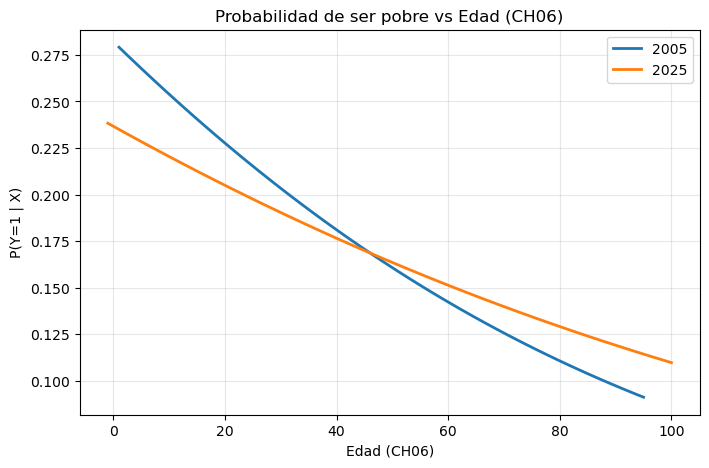

In [56]:
def plot_dos_anios(result_a, X_train_a, year_a, result_b, X_train_b, year_b):
    exog_a = result_a.model.exog_names
    exog_b = result_b.model.exog_names
    for exog, year in [(exog_a, year_a), (exog_b, year_b)]:
        assert "CH06" in exog, f"CH06 no está en el modelo de {year}."

    # Curva año A
    Xa = X_train_a[exog_a].copy()
    ra = np.linspace(int(Xa["CH06"].min()), int(Xa["CH06"].max()), 50)
    Xa_mean = Xa.mean().to_frame().T
    Xa_plot = pd.DataFrame(np.repeat(Xa_mean.values, len(ra), axis=0), columns=exog_a)
    Xa_plot["CH06"] = ra
    ya = result_a.predict(Xa_plot)

    # Curva año B
    Xb = X_train_b[exog_b].copy()
    rb = np.linspace(int(Xb["CH06"].min()), int(Xb["CH06"].max()), 50)
    Xb_mean = Xb.mean().to_frame().T
    Xb_plot = pd.DataFrame(np.repeat(Xb_mean.values, len(rb), axis=0), columns=exog_b)
    Xb_plot["CH06"] = rb
    yb = result_b.predict(Xb_plot)

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(ra, ya, label=str(year_a), lw=2)
    plt.plot(rb, yb, label=str(year_b), lw=2)
    plt.title("Probabilidad de ser pobre vs Edad (CH06)")
    plt.xlabel("Edad (CH06)")
    plt.ylabel("P(Y=1 | X)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_dos_anios(res_2005, X_train_2005, 2005, res_2025, X_train_2025, 2025)


**C. Método de Vecinos Cercanos (KNN)** 

EJERCICIO 5

In [57]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def _prep_features(X):
    X = X.select_dtypes(include=[np.number]).copy()
    # quitar constantes (incluye 'intercepto' si está)
    const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if const_cols:
        X = X.drop(columns=const_cols)
    return X

def knn_estimacion_con_imputacion(X_train, y_train, X_test, y_test, year):
    print(f"\n=== KNN con Imputación & Escalado · Año {year} ===")
    X_train = _prep_features(X_train)
    X_test  = X_test[X_train.columns]  # alinear columnas

    for k in [1, 5, 10]:
        pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        print(f"\nK = {k} | Accuracy: {acc:.3f}")
        print("Matriz de confusión [ [TN FP] ; [FN TP] ]")
        print(cm)

# Ejecutar para 2005 y 2025 con tus splits ya existentes
knn_estimacion_con_imputacion(X_train_2005, y_train_2005, X_test_2005, y_test_2005, 2005)
knn_estimacion_con_imputacion(X_train_2025, y_train_2025, X_test_2025, y_test_2025, 2025)



=== KNN con Imputación & Escalado · Año 2005 ===

K = 1 | Accuracy: 0.734
Matriz de confusión [ [TN FP] ; [FN TP] ]
[[1706  387]
 [ 361  358]]

K = 5 | Accuracy: 0.776
Matriz de confusión [ [TN FP] ; [FN TP] ]
[[1841  252]
 [ 377  342]]

K = 10 | Accuracy: 0.783
Matriz de confusión [ [TN FP] ; [FN TP] ]
[[1915  178]
 [ 431  288]]

=== KNN con Imputación & Escalado · Año 2025 ===

K = 1 | Accuracy: 0.710
Matriz de confusión [ [TN FP] ; [FN TP] ]
[[710 189]
 [186 208]]

K = 5 | Accuracy: 0.770
Matriz de confusión [ [TN FP] ; [FN TP] ]
[[791 108]
 [189 205]]

K = 10 | Accuracy: 0.777
Matriz de confusión [ [TN FP] ; [FN TP] ]
[[815  84]
 [204 190]]


EJERCICIO 6

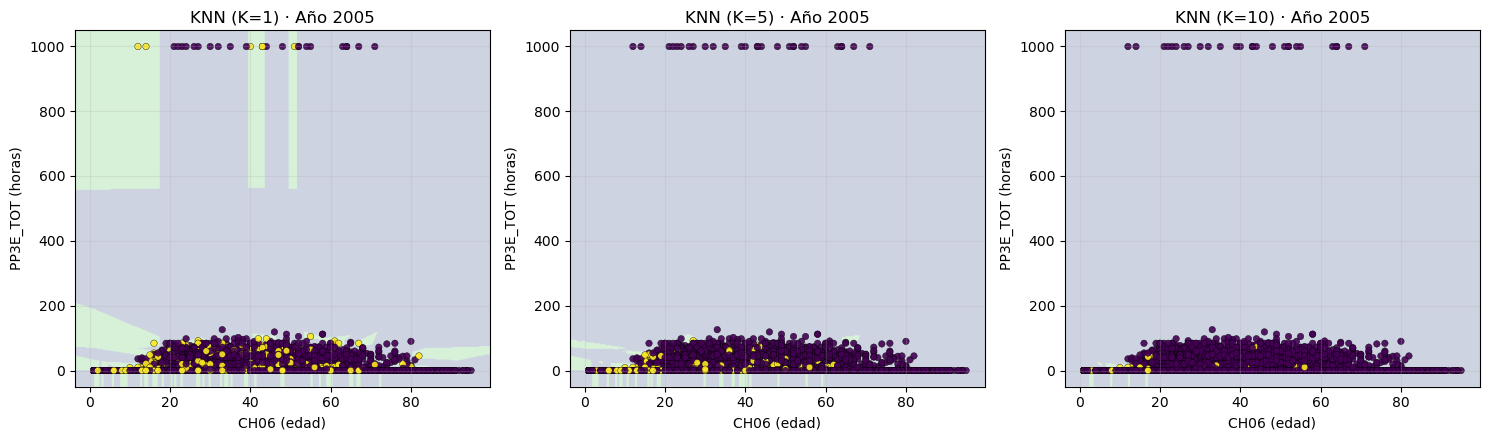

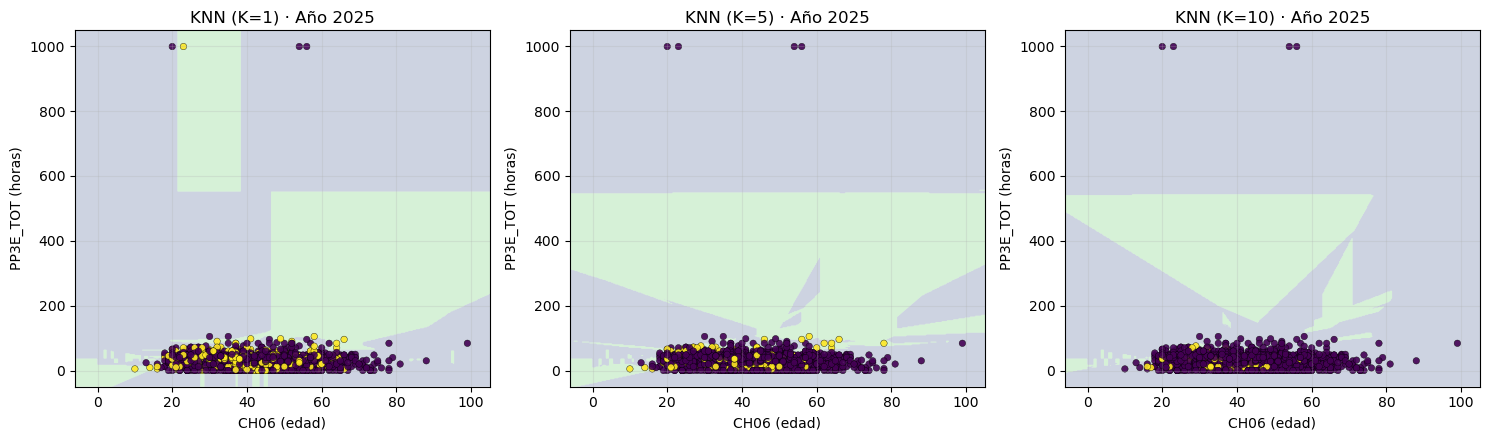

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

def plot_knn_frontiers_two_feats(X_train, y_train, year, feats=("CH06","PP3E_TOT"), ks=(1,5,10)):
    # --- 1) Validaciones y subset de features ---
    f1, f2 = feats
    missing = [f for f in feats if f not in X_train.columns]
    assert not missing, f"Faltan columnas en X_train {year}: {missing}"

    X2 = X_train[[f1, f2]].copy()
    y  = y_train.copy()

    # --- 2) Pipeline: imputar + escalar + KNN (K variable luego) ---
    def train_and_predict_grid(k):
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        pipe.fit(X2, y)

        # Crear malla en el espacio ORIGINAL (no escalado) para que los ejes sean interpretables
        x_min, x_max = X2[f1].min(), X2[f1].max()
        y_min, y_max = X2[f2].min(), X2[f2].max()

        # margencitos
        dx = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
        dy = (y_max - y_min) * 0.05 if y_max > y_min else 1.0
        x_min, x_max = x_min - dx, x_max + dx
        y_min, y_max = y_min - dy, y_max + dy

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 400),
            np.linspace(y_min, y_max, 400)
        )
        grid = pd.DataFrame({f1: xx.ravel(), f2: yy.ravel()})
        Z = pipe.predict(grid).reshape(xx.shape)
        y_pred_train = pipe.predict(X2)

        return xx, yy, Z, y_pred_train

    # --- 3) Plots por cada K ---
    ncols = len(ks)
    plt.figure(figsize=(5*ncols, 4.5))
    for j, k in enumerate(ks, 1):
        xx, yy, Z, y_pred_train = train_and_predict_grid(k)

        ax = plt.subplot(1, ncols, j)
        # Frontera de decisión (pred: 0/1)
        ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5,0.5,1.5], antialiased=True)

        # Puntos del train, coloreados por clase PREDICHA (como pide el enunciado)
        # y con borde para verlos mejor
        scatter = ax.scatter(
            X2[f1], X2[f2],
            c=y_pred_train, s=22, edgecolor="k", linewidth=0.3, alpha=0.9
        )

        ax.set_title(f"KNN (K={k}) · Año {year}")
        ax.set_xlabel(f"{f1} (edad)")
        ax.set_ylabel(f"{f2} (horas)")
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

# Ejecutar para tus conjuntos ya definidos
plot_knn_frontiers_two_feats(X_train_2005, y_train_2005, 2005, feats=("CH06","PP3E_TOT"), ks=(1,5,10))
plot_knn_frontiers_two_feats(X_train_2025, y_train_2025, 2025, feats=("CH06","PP3E_TOT"), ks=(1,5,10))


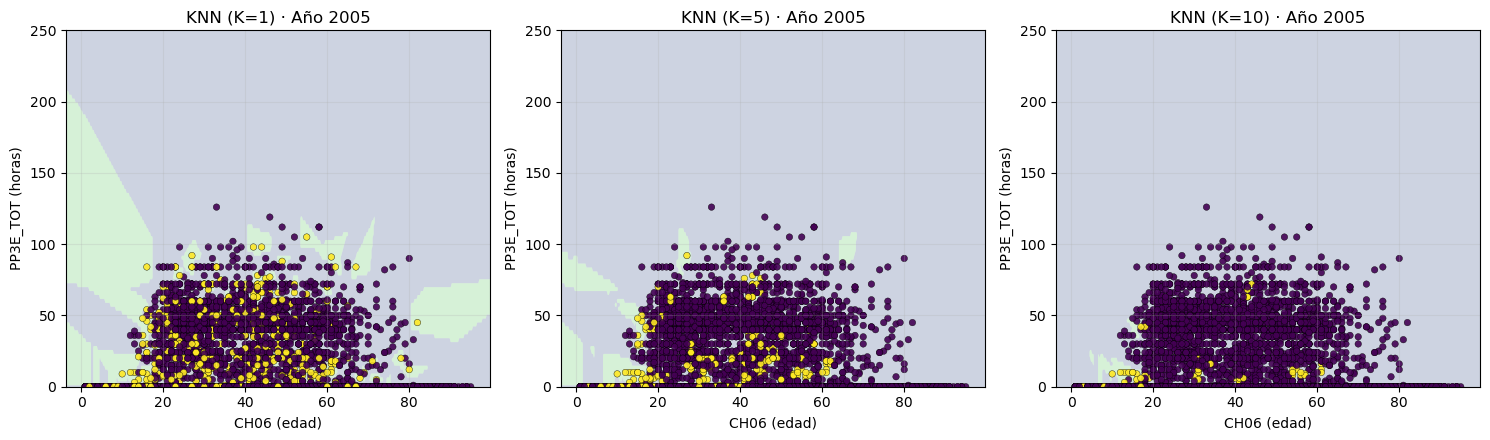

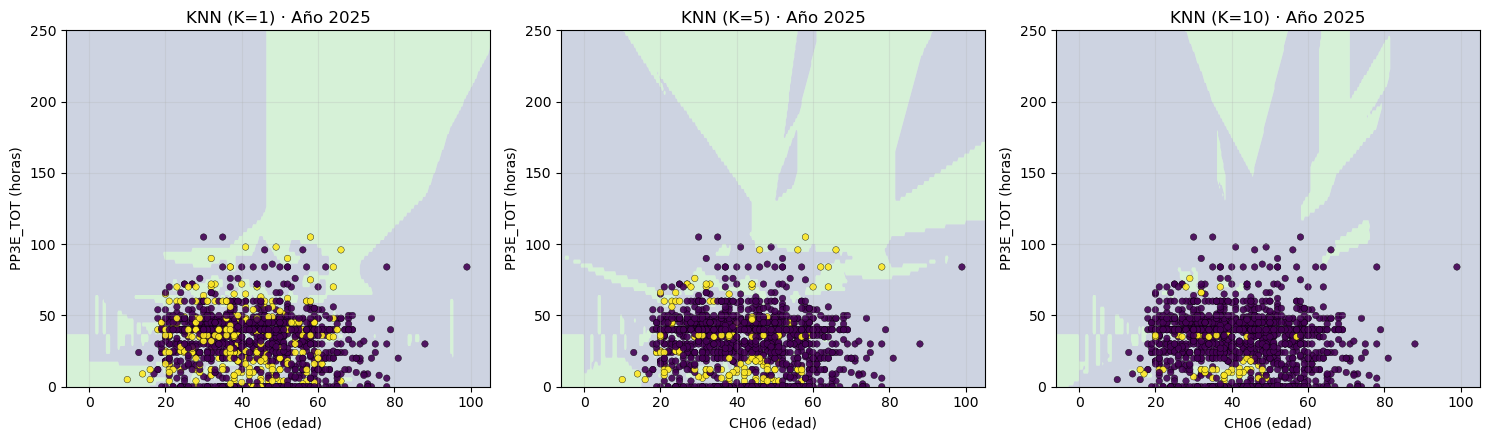

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

def plot_knn_frontiers_two_feats(X_train, y_train, year, feats=("CH06","PP3E_TOT"), ks=(1,5,10)):
    # --- 1) Validaciones y subset de features ---
    f1, f2 = feats
    missing = [f for f in feats if f not in X_train.columns]
    assert not missing, f"Faltan columnas en X_train {year}: {missing}"

    X2 = X_train[[f1, f2]].copy()
    y  = y_train.copy()

    # --- 2) Pipeline: imputar + escalar + KNN (K variable luego) ---
    def train_and_predict_grid(k):
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        pipe.fit(X2, y)

        # Crear malla en el espacio ORIGINAL (no escalado) para que los ejes sean interpretables
        x_min, x_max = X2[f1].min(), X2[f1].max()
        y_min, y_max = X2[f2].min(), X2[f2].max()

        # margencitos
        dx = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
        dy = (y_max - y_min) * 0.05 if y_max > y_min else 1.0
        x_min, x_max = x_min - dx, x_max + dx
        y_min, y_max = y_min - dy, y_max + dy

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 400),
            np.linspace(y_min, y_max, 400)
        )
        grid = pd.DataFrame({f1: xx.ravel(), f2: yy.ravel()})
        Z = pipe.predict(grid).reshape(xx.shape)
        y_pred_train = pipe.predict(X2)

        return xx, yy, Z, y_pred_train

       # --- 3) Plots por cada K ---
    ncols = len(ks)
    plt.figure(figsize=(5*ncols, 4.5))
    for j, k in enumerate(ks, 1):
        xx, yy, Z, y_pred_train = train_and_predict_grid(k)
    
        ax = plt.subplot(1, ncols, j)
        ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5,0.5,1.5], antialiased=True)
    
        scatter = ax.scatter(
            X2[f1], X2[f2],
            c=y_pred_train, s=22, edgecolor="k", linewidth=0.3, alpha=0.9
        )
    
        ax.set_title(f"KNN (K={k}) · Año {year}")
        ax.set_xlabel(f"{f1} (edad)")
        ax.set_ylabel(f"{f2} (horas)")
        ax.grid(alpha=0.25)
    
        # 👉 Limitar el eje Y para mejor visualización
        ax.set_ylim(0, 250)  # ajustá a 200 o 300 según te convenga
    
    plt.tight_layout()
    plt.show()

# Ejecutar para tus conjuntos ya definidos
plot_knn_frontiers_two_feats(X_train_2005, y_train_2005, 2005, feats=("CH06","PP3E_TOT"), ks=(1,5,10))
plot_knn_frontiers_two_feats(X_train_2025, y_train_2025, 2025, feats=("CH06","PP3E_TOT"), ks=(1,5,10))


🟣 Puntos violetas → observaciones clasificadas como “no pobres” (Y = 0) por el modelo KNN.

🟡 Puntos amarillos → observaciones clasificadas como “pobres” (Y = 1) por el modelo KNN.

EJERCICIO 7

K óptimo (5-Fold CV, Accuracy): K = 30 | mean = 0.778 ± 0.006


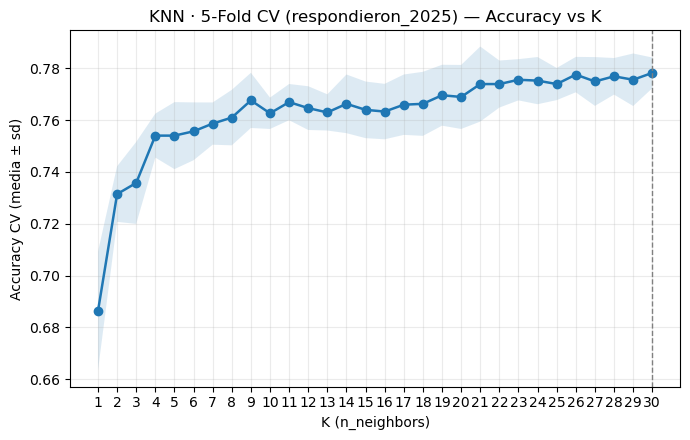

In [60]:
# === KNN con 5-Fold Cross-Validation en respondieron_2025 ===
# Usamos X_train_2025, y_train_2025 ya definidos por vos.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- 0) Subset y limpieza mínima (sin modificar tus originales)
def _prep_cols(X):
    X = X.select_dtypes(include=[np.number]).copy()
    const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if const_cols:
        X = X.drop(columns=const_cols)   # fuera constantes (incluye 'intercepto' si lo dejaste)
    return X

X25 = _prep_cols(X_train_2025)
y25 = y_train_2025.loc[X25.index]

# --- 1) Definimos el CV (como en el tutorial)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

# --- 2) Rango de K a evaluar (podés ampliar si querés)
k_values = list(range(1, 31))  # 1..30

acc_mean, acc_std = [], []

for k in k_values:
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X25, y25, cv=cv5, scoring="accuracy", n_jobs=None)
    acc_mean.append(scores.mean())
    acc_std.append(scores.std(ddof=1))

# --- 3) Elegimos el K óptimo (máxima accuracy media; si empata, el menor K)
best_idx = int(np.argmax(acc_mean))
best_k = k_values[best_idx]
best_acc = acc_mean[best_idx]
best_sd  = acc_std[best_idx]

print(f"K óptimo (5-Fold CV, Accuracy): K = {best_k} | mean = {best_acc:.3f} ± {best_sd:.3f}")

# --- 4) Gráfico estilo tutorial: Accuracy vs K (con barras de desvío)
plt.figure(figsize=(7,4.5))
plt.plot(k_values, acc_mean, marker="o", linewidth=1.8)
plt.fill_between(k_values,
                 np.array(acc_mean) - np.array(acc_std),
                 np.array(acc_mean) + np.array(acc_std),
                 alpha=0.15)
plt.axvline(best_k, color="gray", linestyle="--", linewidth=1)
plt.title("KNN · 5-Fold CV (respondieron_2025) — Accuracy vs K")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy CV (media ± sd)")
plt.xticks(k_values)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# --- 5) Entrenamos el modelo final con K óptimo sobre TODO el X_train_2025
#knn_cv_2025 = Pipeline(steps=[
 #   ("imputer", SimpleImputer(strategy="median")),
 #   ("scaler", StandardScaler()),
 #   ("knn", KNeighborsClassifier(n_neighbors=best_k))
#])
#knn_cv_2025.fit(X25, y25)

# (Opcional) predecir en test:
# ypred_2025 = knn_cv_2025.predict(_prep_cols(X_test_2025)[X25.columns])


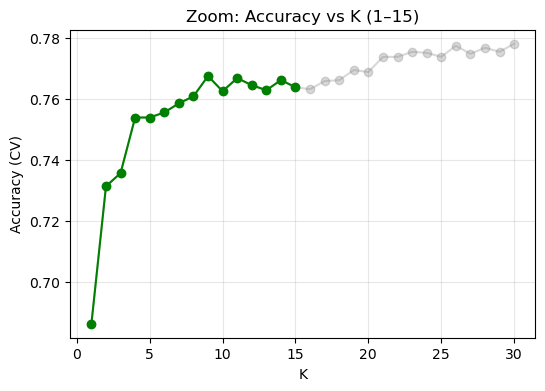

In [61]:
k_values_zoom = range(1, 16)
plt.figure(figsize=(6,4))
plt.plot(k_values, acc_mean, marker='o', color='gray', alpha=0.3)
plt.plot(k_values_zoom, [acc_mean[k-1] for k in k_values_zoom], marker='o', color='green')
plt.title("Zoom: Accuracy vs K (1–15)")
plt.xlabel("K")
plt.ylabel("Accuracy (CV)")
plt.grid(alpha=0.3)
plt.show()


La validación cruzada sugiere que el modelo gana estabilidad con valores altos de K, reflejando que las observaciones son heterogéneas y la separación entre pobres y no pobres no es muy marcada.
No obstante, como la accuracy se estabiliza desde K≈10, se adopta ese valor como compromiso entre sesgo y varianza para el modelo KNN con K-CV.

**D. Desempeño de modelos, elección y predicción afuera de la muestra** 

EJERCICIO 8


📊 Logit 2025 | Accuracy: 0.817 | Recall: 0.385 | AUC: 0.783 | MSE: 0.1331 | R²: 0.156


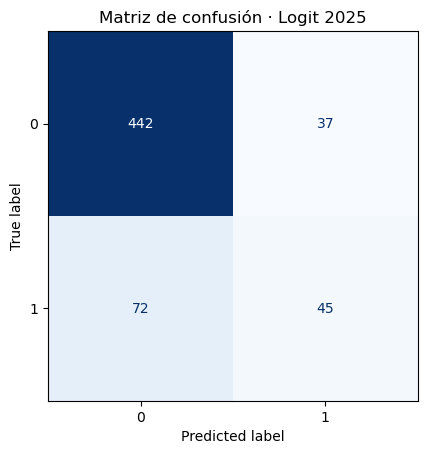


📊 KNN-CV 2025 | Accuracy: 0.810 | Recall: 0.316 | AUC: 0.739 | MSE: 0.1367 | R²: 0.133


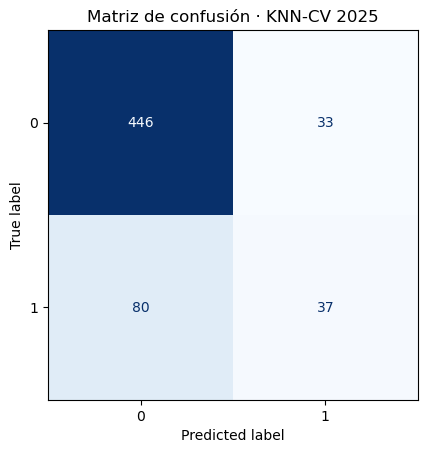

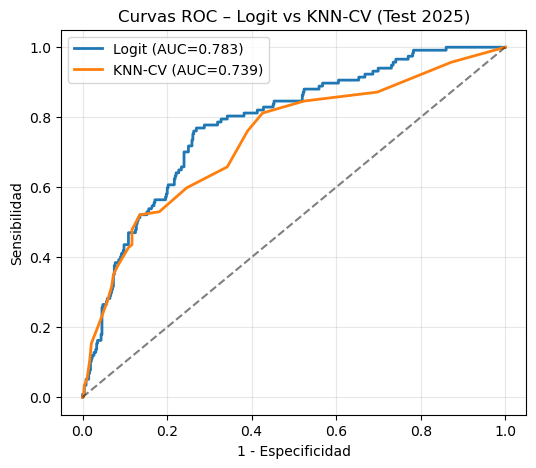

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score, recall_score
)

# ========= Helpers =========
def align_for_logit(X_test, y_test, res_model):
    """
    Alinea X_test a las columnas y orden exactos del modelo Logit (statsmodels).
    Si faltan columnas dummy, las crea en 0; si falta 'intercepto' y el modelo lo usa, la agrega en 1.0.
    """
    exog_cols = res_model.model.exog_names  # orden exacto usado en el fit
    X = X_test.select_dtypes(include=[np.number]).copy()

    # agregar 'intercepto' si el modelo lo tenía y no está en X
    if "intercepto" in exog_cols and "intercepto" not in X.columns:
        X["intercepto"] = 1.0

    # crear columnas faltantes (típicamente dummies) en 0
    faltan = [c for c in exog_cols if c not in X.columns]
    for c in faltan:
        # si es 'intercepto' faltante, poner 1.0; si no, 0.0
        X[c] = 1.0 if c == "intercepto" else 0.0

    # descartar columnas extra y reordenar EXACTO
    X = X[exog_cols].copy()

    # reemplazar ±inf por NaN y dropear filas con NaN para predecir
    X = X.replace([np.inf, -np.inf], np.nan)
    XY = pd.concat([X, y_test.rename("y")], axis=1).dropna(axis=0)
    y_aligned = XY["y"].astype(int)
    X_aligned = XY.drop(columns=["y"])
    return X_aligned, y_aligned


def _prep_cols_knn(X):
    """Mismo criterio que en el fit del KNN-CV: numéricas y sin constantes."""
    X = X.select_dtypes(include=[np.number]).copy()
    const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    if const_cols:
        X = X.drop(columns=const_cols)
    return X

def align_for_knn(X_test, y_test, X_train_used_cols, X_train_for_medians):
    """
    Alinea X_test a las columnas usadas por el KNN-CV (mismo set y orden).
    Crea columnas faltantes con la mediana del train.
    """
    X = _prep_cols_knn(X_test)
    # columnas faltantes respecto del train
    faltan = [c for c in X_train_used_cols if c not in X.columns]
    if faltan:
        med = X_train_for_medians[faltan].median()
        for c in faltan:
            X[c] = med[c]
    # quedarnos solo con las del train y en el MISMO orden
    X = X[X_train_used_cols].copy()

    # y alineamos y
    X = X.replace([np.inf, -np.inf], np.nan)
    XY = pd.concat([X, y_test.rename("y")], axis=1).dropna(axis=0)
    y_aligned = XY["y"].astype(int)
    X_aligned = XY.drop(columns=["y"])
    return X_aligned, y_aligned


def evaluar_modelo(y_true, y_pred, y_proba, titulo):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

     # === Métricas pedidas: MSE (Brier) y R^2 sobre probabilidades ===
    mse = np.mean((y_true - y_proba) ** 2)
    sse = np.sum((y_true - y_proba) ** 2)
    sst = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - sse/sst if sst > 0 else np.nan

    print(f"\n📊 {titulo} | Accuracy: {acc:.3f} | Recall: {rec:.3f} | AUC: {auc:.3f} | MSE: {mse:.4f} | R²: {r2:.3f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title(f"Matriz de confusión · {titulo}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return fpr, tpr, auc

# ========= Evaluación comparativa en TEST 2025 =========
# Partimos de tus objetos:
# res_2025  -> modelo Logit statsmodels ya entrenado
# knn_cv_2025 -> Pipeline KNN (con K óptimo) ya entrenado
# X_train_2025, y_train_2025, X_test_2025, y_test_2025

# --- LOGIT: alinear X_test al modelo
X_logit, y_logit = align_for_logit(X_test_2025, y_test_2025, res_2025)
yhat_proba_logit = res_2025.predict(X_logit)
yhat_logit = (yhat_proba_logit > 0.5).astype(int)
fprL, tprL, aucL = evaluar_modelo(y_logit, yhat_logit, yhat_proba_logit, "Logit 2025")

# --- KNN-CV: alinear X_test a las columnas usadas en el fit
# Si guardaste X25 cuando hiciste CV, úsalo; si no, lo recomponemos con el mismo criterio:
try:
    feat_cols_25 = X25.columns  # del paso de CV si quedó en memoria
    X_train_for_medians = X25.copy()
except NameError:
    X_train_for_medians = _prep_cols_knn(X_train_2025)
    feat_cols_25 = X_train_for_medians.columns

X_knn, y_knn = align_for_knn(X_test_2025, y_test_2025, feat_cols_25, X_train_for_medians)
yhat_knn = knn_cv_2025.predict(X_knn)
yhat_proba_knn = knn_cv_2025.predict_proba(X_knn)[:, 1]
fprK, tprK, aucK = evaluar_modelo(y_knn, yhat_knn, yhat_proba_knn, "KNN-CV 2025")

# --- Curvas ROC comparadas
plt.figure(figsize=(6,5))
plt.plot(fprL, tprL, label=f"Logit (AUC={aucL:.3f})", lw=2)
plt.plot(fprK, tprK, label=f"KNN-CV (AUC={aucK:.3f})", lw=2)
plt.plot([0,1],[0,1],"k--",alpha=0.5)
plt.title("Curvas ROC – Logit vs KNN-CV (Test 2025)")
plt.xlabel("1 - Especificidad")
plt.ylabel("Sensibilidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


EJERCICIO 9

Esta en el informe

EJERCICIO 10

In [63]:
# === Predicción de pobreza en la base norespondieron_2025 usando el modelo LOGIT ===
# Asegurate de tener cargada tu base norespondieron_2025 (con mismas variables que respondieron_2025)

# 1. Alinear columnas al modelo LOGIT (mismo procedimiento que para el test)
X_pred_2025, _ = align_for_logit(norespondieron_2025, pd.Series(np.zeros(len(norespondieron_2025))), res_2025)

# 2. Predecir probabilidades de pobreza
proba_pred_2025 = res_2025.predict(X_pred_2025)

# 3. Clasificar según umbral p > 0.5
yhat_pred_2025 = (proba_pred_2025 > 0.5).astype(int)

# 4. Calcular proporción de personas clasificadas como pobres
prop_pobres_2025 = yhat_pred_2025.mean()

print(f"Proporción de personas clasificadas como pobres en 'norespondieron_2025': {prop_pobres_2025:.3f}")


Proporción de personas clasificadas como pobres en 'norespondieron_2025': 0.000


In [64]:
# 1️⃣ Alinear columnas del norespondieron_2025 con las del modelo Logit
X_pred_2025, _ = align_for_logit(
    norespondieron_2025,
    pd.Series(np.zeros(len(norespondieron_2025))),
    res_2025
)

# 2️⃣ Predecir probabilidades
proba_pred_2025 = res_2025.predict(X_pred_2025)

# 3️⃣ Diagnóstico: rango de probabilidades
print("Rango de probabilidades predichas:")
print("mín:", proba_pred_2025.min(), "máx:", proba_pred_2025.max(), "media:", proba_pred_2025.mean())

# 4️⃣ Elegir umbral adaptado
# Si el promedio está por debajo de 0.5, probá un umbral más inclusivo
umbral = 0.4
yhat_pred_2025 = (proba_pred_2025 > umbral).astype(int)

# 5️⃣ Calcular proporción estimada de pobres
prop_pobres_2025 = yhat_pred_2025.mean()
print(f"\nProporción de personas clasificadas como pobres (umbral={umbral}): {prop_pobres_2025:.3f}")


Rango de probabilidades predichas:
mín: 0.1984083864773808 máx: 0.4793847590344902 media: 0.40001255122027174

Proporción de personas clasificadas como pobres (umbral=0.4): 0.500


Fin!!!!!